In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # 绘图模块，基于matplotlib的可视化python包，但不能完全替代matplotlib，只是对matplotlib的升级
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
%matplotlib inline

## 1.加载数据

In [2]:
#parse_dates:将指定的列加载成日期的格式
offline = pd.read_csv('ccf_offline_stage1_train.csv',parse_dates=['Date_received','Date'])
offline.info()  #175+万条数据

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   User_id        1048575 non-null  int64  
 1   Merchant_id    1048575 non-null  int64  
 2   Coupon_id      629824 non-null   float64
 3   Discount_rate  629824 non-null   object 
 4   Distance       985589 non-null   float64
 5   Date_received  629824 non-null   object 
 6   Date           463717 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 56.0+ MB


In [3]:
offline.head(10)   #NaT:时间日期格式的空值

,User_id,Merchant_id,Coupon_id,Discount_rate,Distance,Date_received,Date
0,1439408,2632,NaN,NaN,0.0,NaN,20250217
1,1439408,4663,11002.0,150:20:00,1.0,20250528,NaN
2,1439408,2632,8591.0,20:01,0.0,20250217,NaN
3,1439408,2632,1078.0,20:01,0.0,20250319,NaN
4,1439408,2632,8591.0,20:01,0.0,20250613,NaN
5,1439408,2632,NaN,NaN,0.0,NaN,20250516
6,1439408,2632,8591.0,20:01,0.0,20250516,20250613
7,1832624,3381,7610.0,200:20:00,0.0,20250429,NaN
8,2029232,3381,11951.0,200:20:00,1.0,20250129,NaN
9,2029232,450,1532.0,30:05:00,0.0,20250530,NaN


## 2.数据的规整

In [4]:
#判断每一列当中有多少个空值
offline.isnull().sum()
#优惠券id，折扣率，领券日期，三者可能存在同时==null的情况

User_id               0
Merchant_id           0
Coupon_id        418751
Discount_rate    418751
Distance          62986
Date_received    418751
Date             584858
dtype: int64

### 2.1把“Discount_rate”列中的满减政策转换成折扣率

In [5]:
offline['Discount_rate'] = offline['Discount_rate'].fillna('null')
offline.head()

,User_id,Merchant_id,Coupon_id,Discount_rate,Distance,Date_received,Date
0,1439408,2632,NaN,null,0.0,NaN,20250217
1,1439408,4663,11002.0,150:20:00,1.0,20250528,NaN
2,1439408,2632,8591.0,20:01,0.0,20250217,NaN
3,1439408,2632,1078.0,20:01,0.0,20250319,NaN
4,1439408,2632,8591.0,20:01,0.0,20250613,NaN


In [6]:
def discount_rate_opt(s): #s代表每一个元素
    if ':' in s:
        split = s.split(':')
        discount_rate = (int(split[0]) - int(split[1]))/int(split[0])
        return round(discount_rate,2)  #折扣率保留两位小数
    elif s == 'null':
        return np.NaN
    else:
        return float(s)

In [7]:
offline['Discount_rate']  = offline['Discount_rate'].map(discount_rate_opt)
offline.head()

,User_id,Merchant_id,Coupon_id,Discount_rate,Distance,Date_received,Date
0,1439408,2632,NaN,NaN,0.0,NaN,20250217
1,1439408,4663,11002.0,0.87,1.0,20250528,NaN
2,1439408,2632,8591.0,0.95,0.0,20250217,NaN
3,1439408,2632,1078.0,0.95,0.0,20250319,NaN
4,1439408,2632,8591.0,0.95,0.0,20250613,NaN


### 2.2 Coupon_id字段：null代表无优惠券，此时Discount_rate与Date_received字段无意义。
检查Coupon_id和Discount_rate与Date_received判断空值和非空值是否一一对应。

In [8]:
#np.all():判断一个课迭代数据中是否都为True，如果是返回True，否则返回False
np.all([True,False,True])

False

In [9]:
nan1 = offline['Coupon_id'].isnull()  #判断优惠券是否为空
nan2 = offline['Date_received'].isnull()   #判断领券日期是否为空
np.all(nan1 == nan2)  #如果结果=true，说明之前的猜测：Coupon_id与Date_received空值与非空值是一一对应的关系

True

In [10]:
nan3 = offline['Discount_rate'].isnull()
np.all(nan1 == nan3)#如果结果=true，说明之前的猜测：Coupon_id与Discount_rate空值与非空值是一一对应的关系

True

### 2.3
如果Date=null & Coupon_id!=null,有券未消费（cpon_no_consume）
如果Date=null & Coupon_id =null,无券未消费（no_cpon_no_consume）
如果Date！=null & Coupon_id=null,无券消费（no_cpon_consume）
如果Date！=null & Coupon_id!=null,有券消费（cpon_consume）

In [11]:
cpon_no_consume = offline[(offline['Date'].isnull() & offline['Coupon_id'].notnull())]
no_cpon_no_consume = offline[(offline['Date'].isnull() & offline['Coupon_id'].isnull())]
no_cpon_consume = offline[(offline['Date'].notnull() & offline['Coupon_id'].isnull())]
cpon_consume = offline[(offline['Date'].notnull() & offline['Coupon_id'].notnull())]

In [13]:
print('有券未消费:{}'.format(len(cpon_no_consume)))
print('无券未消费:{}'.format(len(no_cpon_no_consume)))  #无意义，不分析
print('无券消费:{}'.format(len(no_cpon_consume)))
print('有券消费:{}'.format(len(cpon_consume)))
#用优惠券消费的用7万，相比其他用户来说，占比较少

有券未消费:584858
无券未消费:0
无券消费:418751
有券消费:44966


## 3.数据分析


In [14]:
#绘制饼图占比
consume_status_dict = {'cpon_no_consume':len(cpon_no_consume),'no_cpon_consume':len(no_cpon_consume),'cpon_consume':len(cpon_consume)}
consume_status = pd.Series(consume_status_dict)
consume_status

cpon_no_consume    584858
no_cpon_consume    418751
cpon_consume        44966
dtype: int64

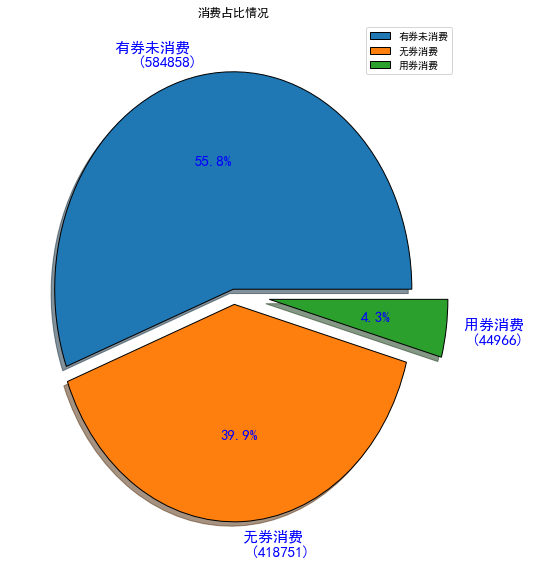

In [15]:
#消费方式构成的饼图（figure：看作是一张画布，axes：代表画布内的多个坐标系）
fig,ax=plt.subplots(1,1,figsize=(8,10))
consume_status.plot.pie(ax = ax,
                       autopct='%1.1f%%',
                       shadow=True,
                        explode=[0.02,0.05,0.2],
                        textprops={'fontsize':15,'color':'blue'},
                        wedgeprops={'linewidth':1,'edgecolor':'black'},
                        labels=['有券未消费 \n ({})'.format(len(cpon_no_consume)),
                                '无券消费 \n ({})'.format(len(no_cpon_consume)),
                               '用券消费 \n ({})'.format(len(cpon_consume))
                               ]
                       )
ax.set_ylabel('')  #去除ylable
ax.set_title('消费占比情况')
plt.legend(labels=['有券未消费','无券消费','用券消费'])
#有券未消费占比55.7%最大，说明大多数人拿完券之后，尚未使用
#无圈消费用户占比40%，说明很多人没有使用优惠券，可能优惠券的吸引力不大，客户没在意；可能，新用户比较多。
#用券消费用户占比较小4.3%,说明我们的优惠券使用率不高。可以考虑是不是加大优惠券力度...

## 3.1在有券消费人群中，分析距离和优惠折扣

In [16]:
#各商家对应的顾客到店平均距离
Merchant_distance = cpon_consume.groupby('Merchant_id')['Distance'].mean()
Merchant_distance[Merchant_distance==0]
#有4076个商家，有1431个商家的用券消费用户平均范围在500米以内

Merchant_id
3       0.0
4       0.0
13      0.0
14      0.0
20      0.0
       ... 
8778    0.0
8793    0.0
8795    0.0
8824    0.0
8828    0.0
Name: Distance, Length: 1237, dtype: float64

Merchant_id
3       0.670000
4       0.830000
5       0.750000
13      0.900000
14      0.830000
          ...   
8839    0.953333
8840    0.950000
8843    0.933333
8844    0.892500
8850    0.950000
Name: Discount_rate, Length: 3296, dtype: float64

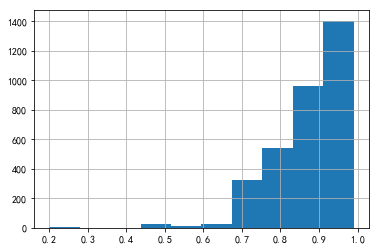

In [17]:
#各商家对应的顾客到店消费平均折扣力度
Merchant_discount_rate = cpon_consume.groupby('Merchant_id')['Discount_rate'].mean()
Merchant_discount_rate.sort_values()
Merchant_discount_rate.hist()
Merchant_discount_rate.mean()  #所有商家平均折扣的平均值：0.88
Merchant_discount_rate

## 3.2持券到店消费人数最多的商家

In [18]:
#对商家进行分组，取出用户id，对用户id进行去重统计数量、
popular_merchant = cpon_consume.groupby('Merchant_id')['User_id'].apply(lambda x:len(x.unique())).sort_values(ascending=False)
#找出持券消费人数>500的商家id
popular_merchant500 = popular_merchant[popular_merchant>500]
popular_merchant500.name = 'customer_count'  #指定列名为消费者数量（持券消费者）
print(len(popular_merchant500))
print(popular_merchant500)
#共有16家店铺，持券消费人数在500人以上
#持券消费人数最多商家是5341，持券消费人数在2800
#排名最后的商家，持券消费人数未559人
#这批商家对优惠券的使用方法得当，消费者喜欢用优惠券进行消费，可以适当借鉴这批商家的推广力度

12
Merchant_id
5341    1652
760     1527
3381    1274
6485    1198
2099     845
2934     812
450      661
7555     573
3532     559
1520     526
4142     503
6901     502
Name: customer_count, dtype: int64


## 3.3持券消费人数在500人以上的商家，连接顾客到店平均距离和平均折扣力度

In [19]:
merchant_pop_dis = pd.merge(left=popular_merchant500,right=Merchant_distance,on='Merchant_id',how='inner')
merchant_pop_dis_rate = pd.merge(left=merchant_pop_dis,right=Merchant_discount_rate,on='Merchant_id',how='inner')
merchant_pop_dis_rate

,customer_count,Distance,Discount_rate
Merchant_id,,,
5341,1652,0.182232,0.825942
760,1527,0.336247,0.799251
3381,1274,1.641216,0.747143
6485,1198,0.391279,0.771763
2099,845,0.926559,0.900000
2934,812,1.127353,0.830000
450,661,0.827338,0.819921
7555,573,1.415307,0.828123
3532,559,0.241431,0.852250


## 3.4计算到店消费人数与平均距离和折扣力度的相关系数

In [20]:
#corr(correlation:相关系数)，用来计算df数据中列与列的相关性（皮尔逊相关系数），取值范围[-1,1]之间
#1：完全正相关，-1：完全负相关
#绝对值越大：相关性越大，反之成立
#正相关：随着变量的增大，而增大，反之同理
#负相关：随着变量的增大，而减小，反之同理
merchant_pop_dis_rate.corr()
#持券消费人数，与距离和折扣率都呈现出负相关，属于生活中的正常现象

,customer_count,Distance,Discount_rate
customer_count,1.000000,-0.193384,-0.593229
Distance,-0.193384,1.000000,-0.242940
Discount_rate,-0.593229,-0.242940,1.000000


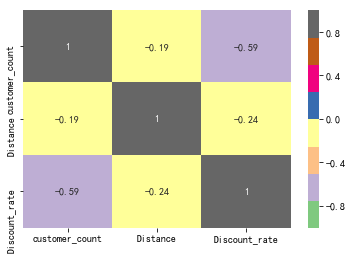

In [21]:
#用热力图展示相关系数(data:相关系数，annot：显示相关系数值，cmap：颜色范围，vmax：最大值，vmin：最小值)
sns.heatmap(data=merchant_pop_dis_rate.corr(),annot=True,cmap='Accent',vmax=1,vmin=-1)

In [22]:
#由图可知：
#1.到店消费人数的多少与顾客到店铺的距离之间呈现负相关，相关系数0.31，在0.3~0.5之间，为低度相关
#2.到店消费人数的多少与优惠打折力度呈现负相关，相关系数0.2，在0~0.3之间，为相关程度极弱
#综上所述，这些店家之所以火爆，应该是物美价廉导致，与距离和优惠力度相关性不大

## 4.1分析每天中优惠券的总体发放量与使用量情况

In [23]:
#业务分析：日期（优惠券的发放日期Date_received，使用日期date）用作图表的x轴
#需要统计每天优惠券发放数量和使用数量

In [24]:
offline['Date'].notnull().sum()  #77.7万消费数据

463717

In [25]:
offline['Date_received'].notnull().sum()  #已经发送出105万优惠券

629824

In [26]:
#取出存在消费日期的记录，进行升序，再去重
date_sort = offline[offline['Date'].notnull()]['Date'].sort_values().unique()
date_sort[:5]

array(['20250101', '20250102', '20250103', '20250104', '20250105'],
      dtype=object)

In [27]:
#取出存在领券日期的记录，进行升序，再去重
date_receive_sort = offline[offline['Date_received'].notnull()]['Date_received'].sort_values().unique()
date_receive_sort[:5]

array(['20250101', '20250102', '20250103', '20250104', '20250105'],
      dtype=object)

In [28]:
#每天优惠券的使用量（即持券消费人群）
consume_num_everday =  cpon_consume[['User_id','Date_received']]
consume_num_everday = consume_num_everday.groupby('Date_received').count()
consume_num_everday = consume_num_everday.rename(columns={'User_id':'count'})
consume_num_everday

,count
Date_received,
20250101,48
20250102,43
20250103,49
20250104,60
20250105,68
...,...
20250611,210
20250612,199
20250613,275


In [29]:
#每天发放的优惠券数量(取出所有领券日期！=null的数据，在进行按天分组，计数就可以)
coupon_sendout_everyday = offline[offline['Date_received'].notnull()][['Date_received','User_id']]
coupon_sendout_everyday = coupon_sendout_everyday.groupby('Date_received').count()
coupon_sendout_everyday = coupon_sendout_everyday.rename(columns={'User_id':'count'})
coupon_sendout_everyday

,count
Date_received,
20250101,340
20250102,334
20250103,341
20250104,337
20250105,396
...,...
20250611,3087
20250612,2412
20250613,4740


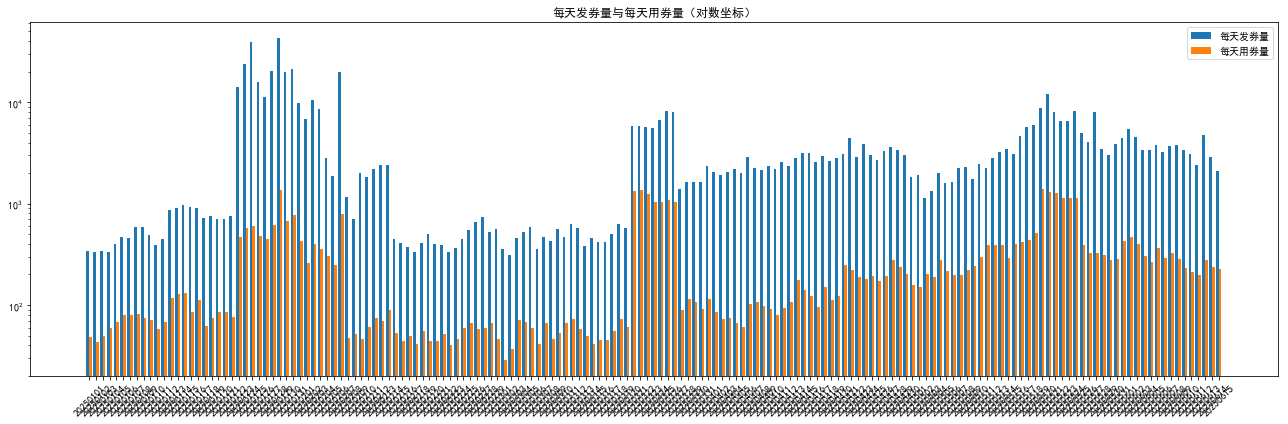

In [34]:
# 绘制每天发券量和每天用券量
# 1. 将索引（日期）重置为列，方便合并
df_send = coupon_sendout_everyday.reset_index().rename(columns={'Date_received':'date', 'count':'send_count'})
df_cons = consume_num_everday.reset_index().rename(columns={'Date_received':'date', 'count':'use_count'})

# 2. 按日期外连接合并，保证日期对齐
df = pd.merge(df_send, df_cons, on='date', how='outer').sort_values('date')

# 3. 缺失值填0
df['send_count'] = df['send_count'].fillna(0)
df['use_count'] = df['use_count'].fillna(0)

# 4. 准备绘图数据
dates = df['date'].astype(str)  # 转成字符串方便显示
send = df['send_count'].values
use = df['use_count'].values

x = np.arange(len(dates))
width = 0.4

# 5. 绘制柱状图
plt.figure(figsize=(18,6))
plt.bar(x - width/2, send, width=width, label='每天发券量')
plt.bar(x + width/2, use, width=width, label='每天用券量')
plt.yscale('log')  # y轴对数缩放

plt.xticks(x, dates, rotation=45)
plt.legend()
plt.title('每天发券量与每天用券量（对数坐标）')
plt.tight_layout()
plt.show()
# 25年2月为例，用券量级别再1000，发券量再10万左右，在100倍左右，优惠券的使用率还是非常低的

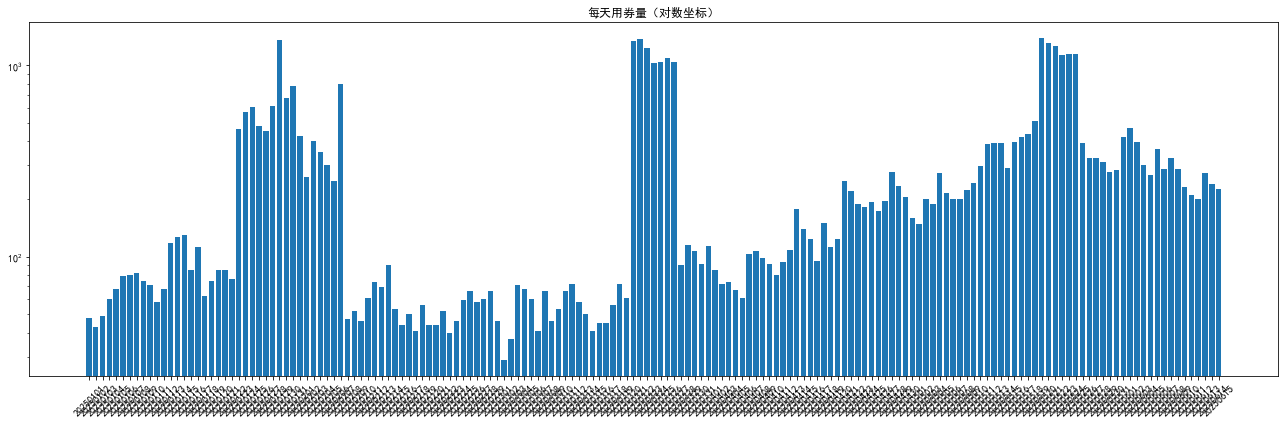

In [35]:
dates = consume_num_everday.index.astype(str)
use_count = consume_num_everday['count'].values

plt.figure(figsize=(18,6))
plt.bar(dates, use_count)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title('每天用券量（对数坐标）')
plt.tight_layout()
plt.show()

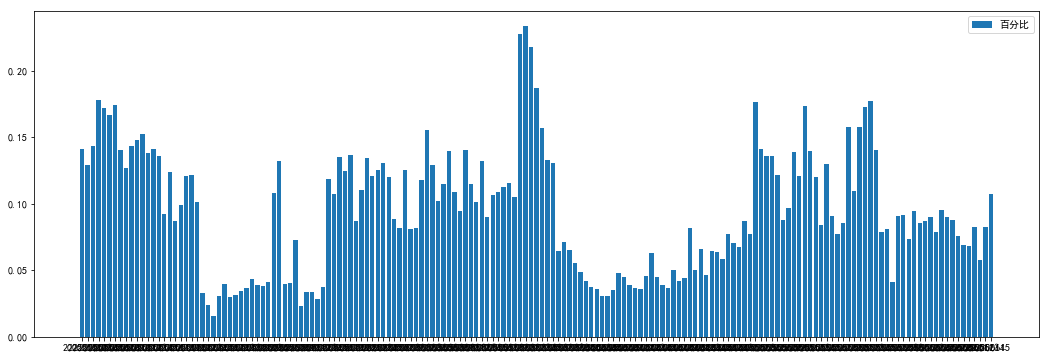

In [36]:
# 计算每天的优惠券与发券量占比
plt.figure(figsize=(18,6))
plt.bar(x=date_receive_sort,height=consume_num_everday['count']/coupon_sendout_everyday['count'],
       label='百分比')
plt.legend()

In [37]:
#由图可知，优惠券使用率最高在25年3月底，达到了30%
#使用率最低在25年1月底，最低为3%左右。
#整体来看，优惠券使用率波动较大。